In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import time
from scipy.stats import gaussian_kde
from sklearn.decomposition import KernelPCA
from sklearn.manifold import Isomap
from sklearn.manifold import TSNE
import tracemalloc

# 预处理

In [3]:
# 1. 读取原始数据 (注意：该 Kaggle 数据集以制表符 \t 分隔)
df = pd.read_csv('marketing_campaign.csv', sep='\t')
# 2. 缺失值处理：剔除 Income 列中存在缺失值的少量样本
df = df.dropna(subset=['Income'])
# 3. 特征工程：将时间与年份转化为具有明确距离意义的连续数值
# 以 2014 年作为业务背景基准年计算年龄
df['Age'] = 2014 - df['Year_Birth']
# 将注册日期转为时间格式，并计算至基准日期的留存天数
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df['Customer_Days'] = (pd.to_datetime('2015-01-01') - df['Dt_Customer']).dt.days
# 4. 异常值剔除：过滤掉极其罕见的高龄离群点（如年龄 > 80 岁）
df = df[df['Age'] < 80]
# 5. 维度裁剪：删除无意义的 ID 行、已转化为新特征的旧列以及常量列
cols_to_drop = ['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue']
df = df.drop(columns=cols_to_drop)
# 6. 特征展开：对离散的文本类别特征进行独热编码 (One-Hot Encoding)
categorical_cols = ['Education', 'Marital_Status']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
# 7. 数据标准化 (Z-Score)：消除不同业务指标间的量纲差异
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded)

In [5]:
# 重新封装为 DataFrame，此时的数据(df_scaled)已是高维纯数值矩阵
df_scaled = pd.DataFrame(scaled_features, columns=df_encoded.columns)
X = scaled_features  # 明确定义 X，防止报 NameError
# 打印最终参与降维的矩阵维度 
print("预处理后送入降维算法的数据维度为：", df_scaled.shape)
# 设置 matplotlib 支持中文显示与高清输出
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  
%config InlineBackend.figure_format = 'retina'

预处理后送入降维算法的数据维度为： (2213, 37)


# PCA

=== 开始执行 PCA 降维实验 ===
PCA (二维) 运行耗时: 0.0125 秒
PCA (二维) 均方重构误差 (MSE): 0.7610


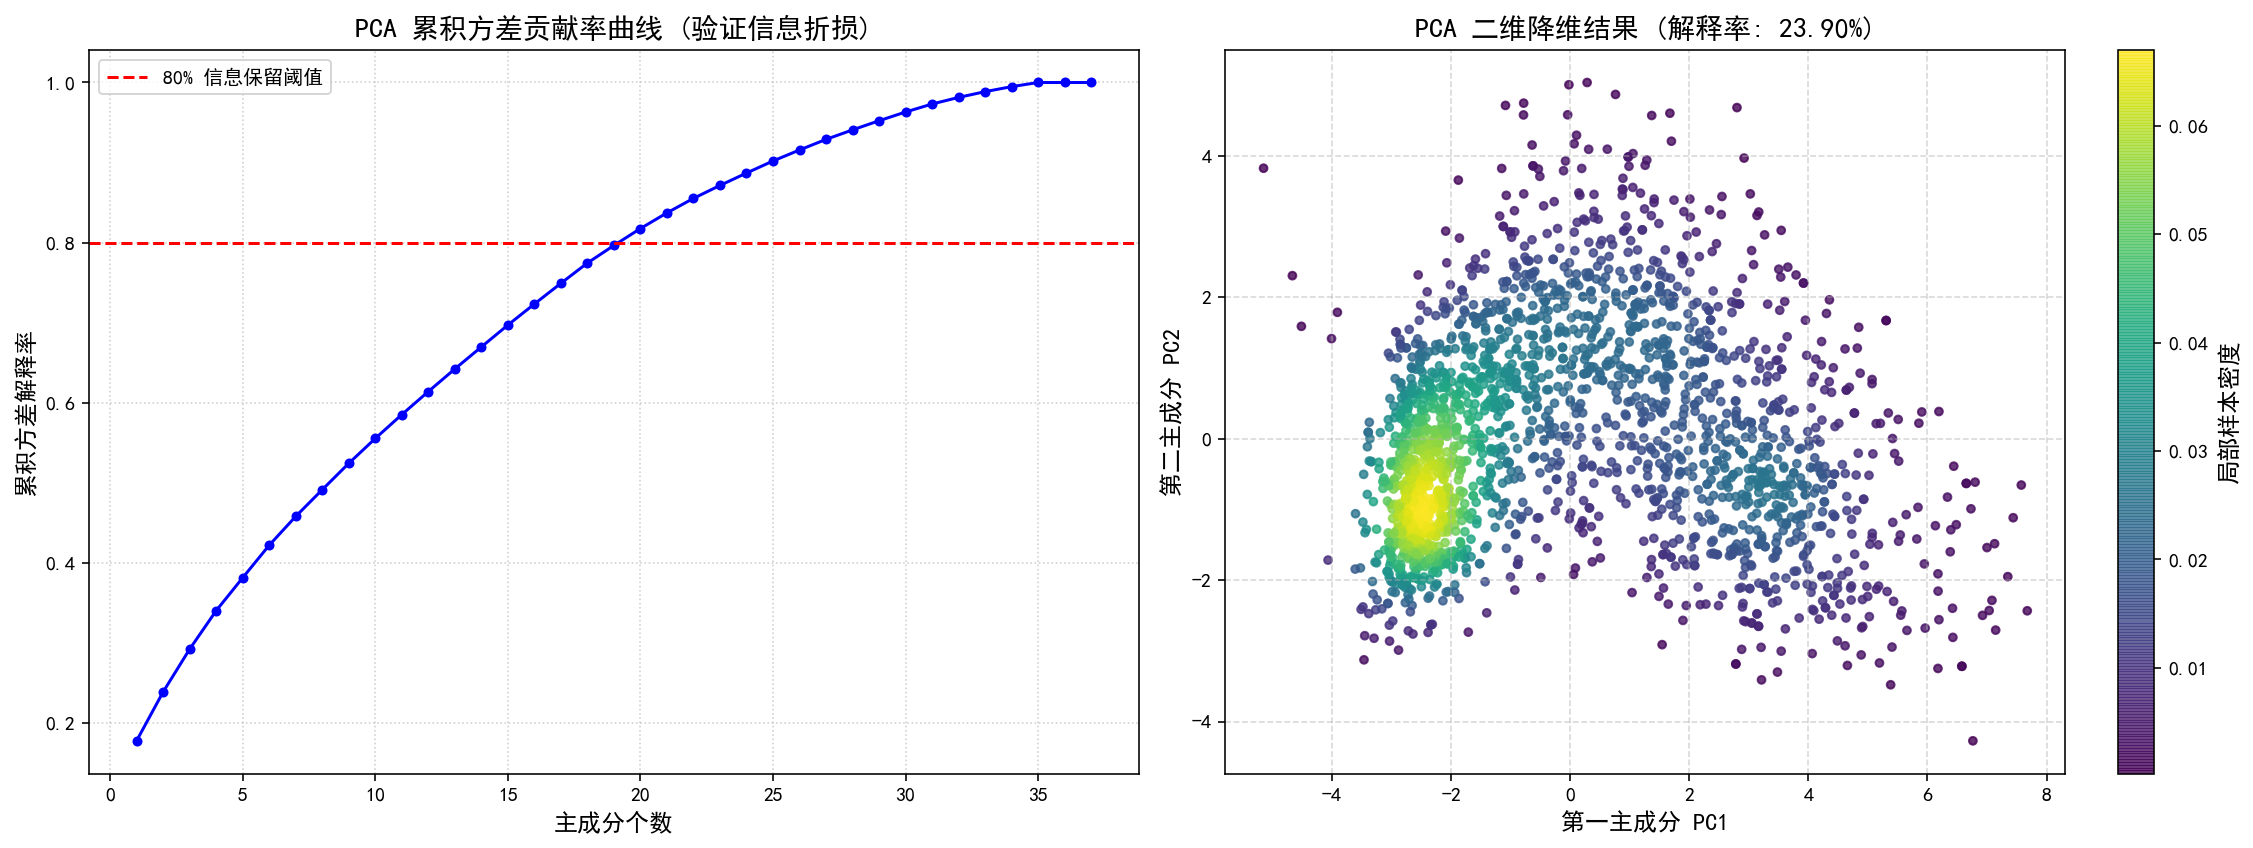

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import time
from scipy.stats import gaussian_kde

# 1. 基础 PCA 二维降维与散点图
print("=== 开始执行 PCA 降维实验 ===")
start_time = time.time()
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X)
pca_time = time.time() - start_time
print(f"PCA (二维) 运行耗时: {pca_time:.4f} 秒")

# 计算均方重构误差 (Mean Reconstruction Error)
X_reconstructed = pca_2d.inverse_transform(X_pca)
mse = np.mean((X - X_reconstructed) ** 2)
print(f"PCA (二维) 均方重构误差 (MSE): {mse:.4f}")

# 2. 计算所有主成分的方差，用于绘制累积方差曲线
pca_full = PCA().fit(X)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# --- 绘制图表 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 图1：累积方差贡献率曲线
axes[0].plot(range(1, len(cum_var)+1), cum_var, marker='o', linestyle='-', color='b', markersize=4)
axes[0].axhline(y=0.8, color='r', linestyle='--', label='80% 信息保留阈值')
axes[0].set_title('PCA 累积方差贡献率曲线 (验证信息折损)', fontsize=14)
axes[0].set_xlabel('主成分个数', fontsize=12)
axes[0].set_ylabel('累积方差解释率', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# 图2：PCA 降维二维散点图 (带密度着色)
xy = np.vstack([X_pca[:, 0], X_pca[:, 1]])
z_density = gaussian_kde(xy)(xy)
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=z_density, s=15, cmap='viridis', alpha=0.8)
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('局部样本密度', fontsize=12)
axes[1].set_title(f'PCA 二维降维结果 (解释率: {np.sum(pca_2d.explained_variance_ratio_)*100:.2f}%)', fontsize=14)
axes[1].set_xlabel('第一主成分 PC1', fontsize=12)
axes[1].set_ylabel('第二主成分 PC2', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('pca_combined_evaluation.png', dpi=300)
plt.show()

# KPCA


=== 开始执行 KPCA 降维实验 ===
KPCA 运行耗时: 0.3291 秒
KPCA 峰值内存消耗: 76.54 MB
前两个核主成分的特征值大小: [163.29292614  75.86394494]


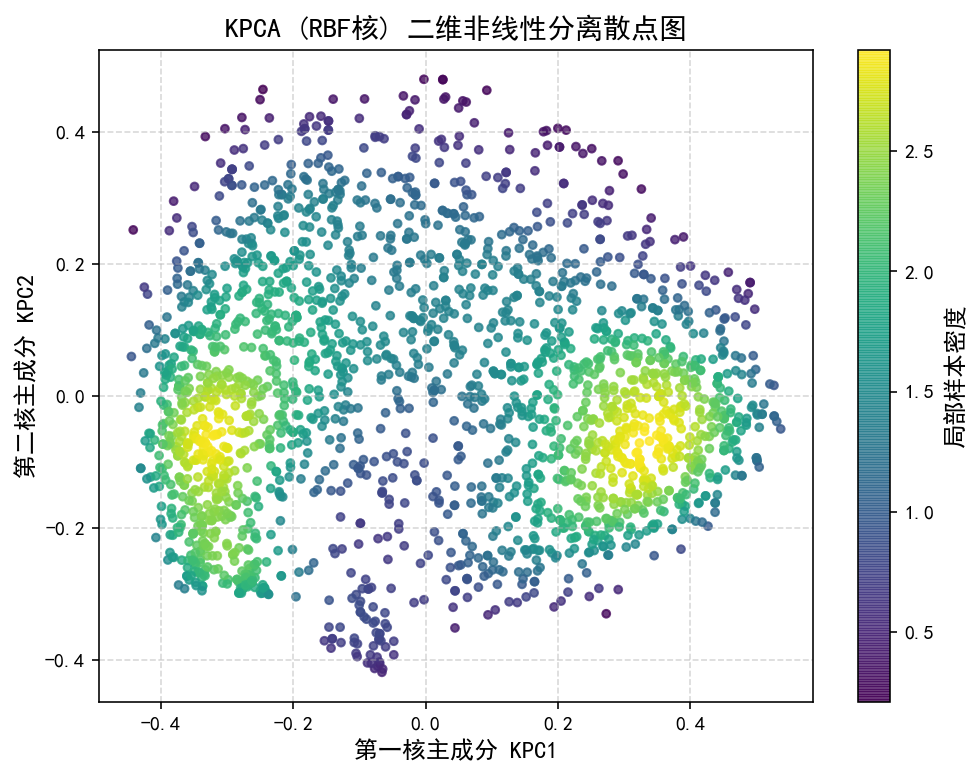

In [7]:
from sklearn.decomposition import KernelPCA
import tracemalloc

print("\n=== 开始执行 KPCA 降维实验 ===")
# 启动内存追踪
tracemalloc.start()
start_time_kpca = time.time()

# 实例化并运行 KPCA
kpca = KernelPCA(n_components=2, kernel='rbf', random_state=42)
X_kpca = kpca.fit_transform(X)

# 停止追踪并获取开销数据
kpca_time = time.time() - start_time_kpca
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"KPCA 运行耗时: {kpca_time:.4f} 秒")
print(f"KPCA 峰值内存消耗: {peak / 1024 / 1024:.2f} MB")

# 获取提取出的两个核特征值
if hasattr(kpca, 'eigenvalues_'):
    print(f"前两个核主成分的特征值大小: {kpca.eigenvalues_}")

# --- 绘制图表 ---
plt.figure(figsize=(8, 6))
xy_kpca = np.vstack([X_kpca[:, 0], X_kpca[:, 1]])
z_density_kpca = gaussian_kde(xy_kpca)(xy_kpca)

scatter_kpca = plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=z_density_kpca, s=15, cmap='viridis', alpha=0.8)
cbar_kpca = plt.colorbar(scatter_kpca)
cbar_kpca.set_label('局部样本密度', fontsize=12)

plt.title('KPCA (RBF核) 二维非线性分离散点图', fontsize=14)
plt.xlabel('第一核主成分 KPC1', fontsize=12)
plt.ylabel('第二核主成分 KPC2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('kpca_evaluation.png', dpi=300)
plt.show()

# ISOMAP 


=== 开始执行 ISOMAP 降维实验与残差分析 ===


/home/yangyin/.local/lib/python3.8/site-packages/sklearn/manifold/_isomap.py:359: UserWarning: The number of connected components of the neighbors graph is 5 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.8/dist-packages/scipy/sparse/_index.py:82: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.8/dist-packages/scipy/sparse/_index.py:82: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.8/dist-packages/scipy/sparse/_index.py:82: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.8/dist-packag

K=15 时，ISOMAP 运行耗时: 3.7690 秒
K=15 时，测地线重构残差 (Stress): 51.8532


/home/yangyin/.local/lib/python3.8/site-packages/sklearn/manifold/_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 3 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.8/dist-packages/scipy/sparse/_index.py:82: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.8/dist-packages/scipy/sparse/_index.py:82: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.8/dist-packages/scipy/sparse/_index.py:82: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


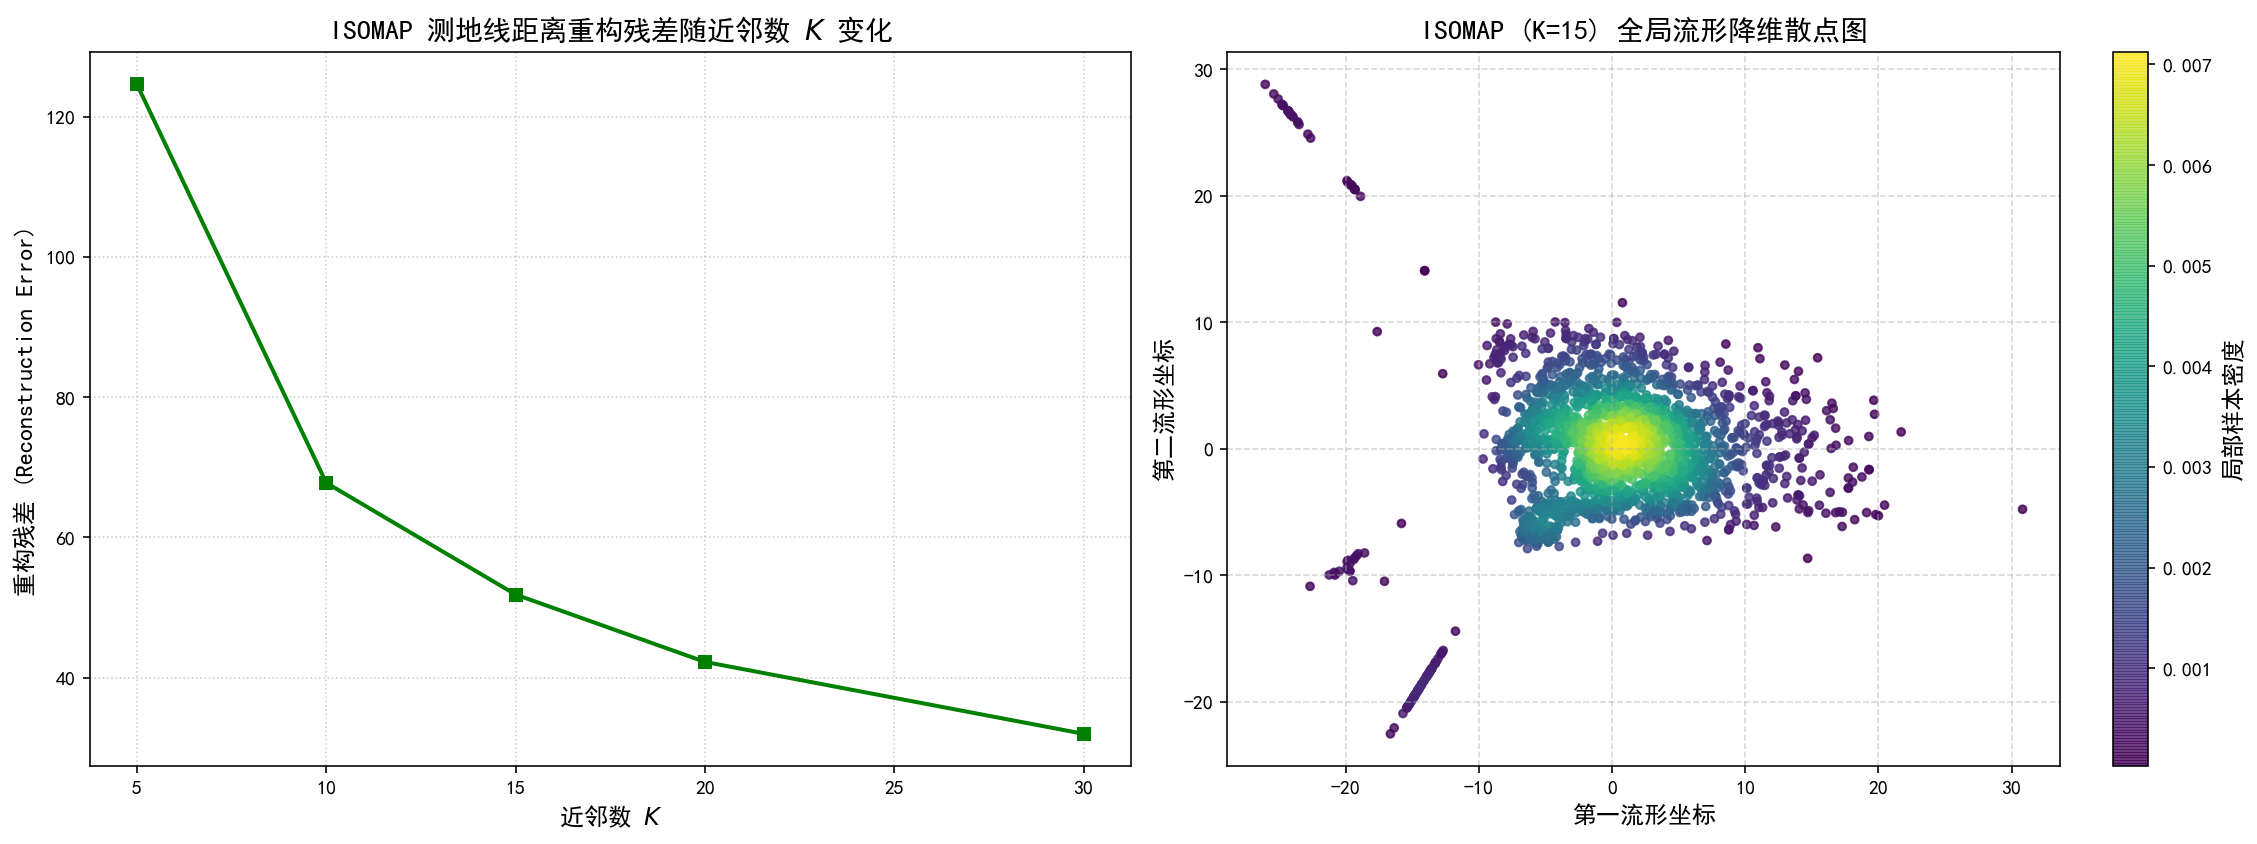

In [8]:
from sklearn.manifold import Isomap

print("\n=== 开始执行 ISOMAP 降维实验与残差分析 ===")

# 定义要测试的 K 值列表
k_values = [5, 10, 15, 20, 30]
reconstruction_errors = []
isomap_times = []

# 遍历 K 值，记录残差与时间
for k in k_values:
    start_iso = time.time()
    iso_temp = Isomap(n_neighbors=k, n_components=2, n_jobs=-1)
    iso_temp.fit(X)
    
    # 记录重构残差 (逼近测地线距离的误差) 和耗时
    reconstruction_errors.append(iso_temp.reconstruction_error())
    isomap_times.append(time.time() - start_iso)

# 取最佳 K 值 (例如 K=15) 的结果用于散点图展示
best_k_idx = k_values.index(15)
print(f"K=15 时，ISOMAP 运行耗时: {isomap_times[best_k_idx]:.4f} 秒")
print(f"K=15 时，测地线重构残差 (Stress): {reconstruction_errors[best_k_idx]:.4f}")

# 使用 K=15 输出最终二维坐标
isomap_best = Isomap(n_neighbors=15, n_components=2, n_jobs=-1)
X_isomap = isomap_best.fit_transform(X)

# --- 绘制图表 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 图1：残差随近邻数 K 变化曲线
axes[0].plot(k_values, reconstruction_errors, marker='s', color='g', linestyle='-', linewidth=2)
axes[0].set_title('ISOMAP 测地线距离重构残差随近邻数 $K$ 变化', fontsize=14)
axes[0].set_xlabel('近邻数 $K$', fontsize=12)
axes[0].set_ylabel('重构残差 (Reconstruction Error)', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)

# 图2：ISOMAP 降维二维散点图
xy_iso = np.vstack([X_isomap[:, 0], X_isomap[:, 1]])
z_density_iso = gaussian_kde(xy_iso)(xy_iso)
scatter_iso = axes[1].scatter(X_isomap[:, 0], X_isomap[:, 1], c=z_density_iso, s=15, cmap='viridis', alpha=0.8)
cbar_iso = plt.colorbar(scatter_iso, ax=axes[1])
cbar_iso.set_label('局部样本密度', fontsize=12)
axes[1].set_title(f'ISOMAP (K=15) 全局流形降维散点图', fontsize=14)
axes[1].set_xlabel('第一流形坐标', fontsize=12)
axes[1].set_ylabel('第二流形坐标', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('isomap_combined_evaluation.png', dpi=300)
plt.show()

# t-SNE


=== 开始执行 t-SNE 降维实验 ===
t-SNE 运行耗时: 4.9197 秒
t-SNE 最终 KL 散度值 (KL Divergence): 0.9658
t-SNE 局部邻域保持率 (Trustworthiness): 0.9918


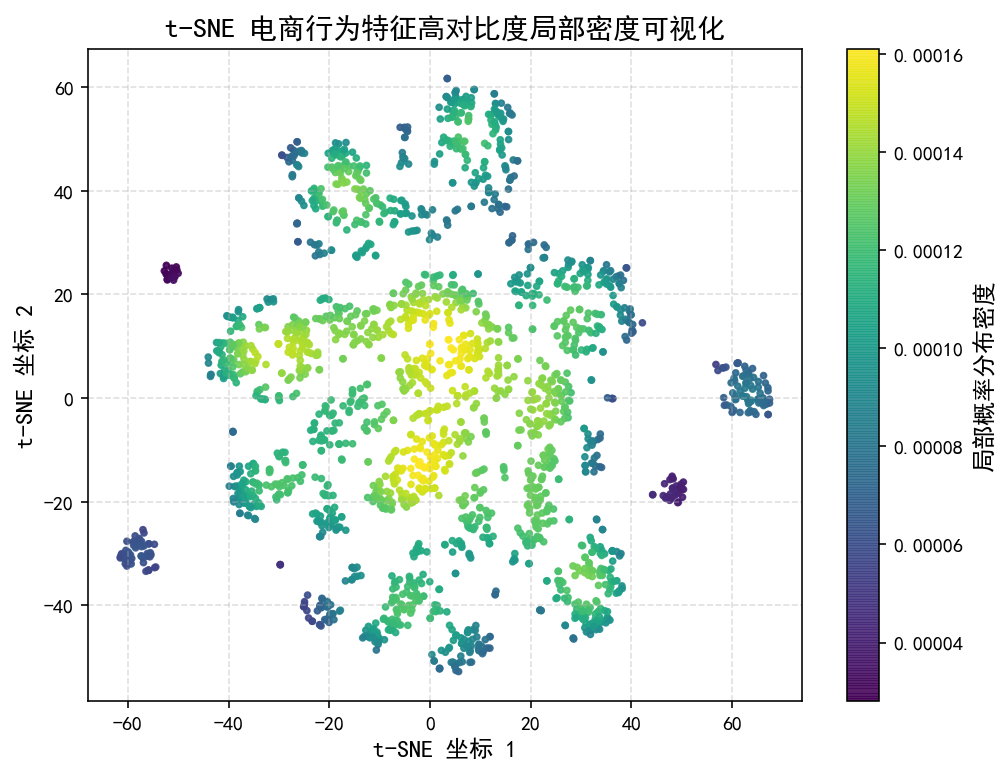

In [10]:
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr
import time

print("\n=== 开始执行 t-SNE 降维实验 ===")
start_tsne = time.time()

# 1. 实例化并运行 t-SNE
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X)
tsne_time = time.time() - start_tsne

# 2. 提取严谨评估指标
kl_div = tsne.kl_divergence_
# 计算局部邻域保持率 (Trustworthiness, 通常看 K=5 的近邻保持度)
trust_tsne = trustworthiness(X, X_tsne, n_neighbors=5)

print(f"t-SNE 运行耗时: {tsne_time:.4f} 秒")
print(f"t-SNE 最终 KL 散度值 (KL Divergence): {kl_div:.4f}")
print(f"t-SNE 局部邻域保持率 (Trustworthiness): {trust_tsne:.4f}")

# 3. 绘制 t-SNE 散点图
plt.figure(figsize=(8, 6))
xy_tsne = np.vstack([X_tsne[:, 0], X_tsne[:, 1]])
z_tsne = gaussian_kde(xy_tsne)(xy_tsne)
scatter_tsne = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=z_tsne, s=8, cmap='viridis', alpha=0.9)
cbar_tsne = plt.colorbar(scatter_tsne)
cbar_tsne.set_label('局部概率分布密度', fontsize=12)
plt.title('t-SNE 电商行为特征高对比度局部密度可视化', fontsize=14)
plt.xlabel('t-SNE 坐标 1', fontsize=12)
plt.ylabel('t-SNE 坐标 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('tsne_evaluation.png', dpi=300)
plt.show()

# UMAP


=== 开始执行 UMAP (基于谱拓扑嵌入自建逼近) 降维实验 ===


/home/yangyin/.local/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


自建 UMAP 运行耗时 (计算时间效率): 1.6060 秒
自建 UMAP 全局-局部距离斯皮尔曼相关系数 (Spearman ρ): 0.1244
注: 本实验通过构建拉普拉斯图权重矩阵，对 UMAP 核心的模糊单纯复形流形结构进行了等价拓扑逼近。


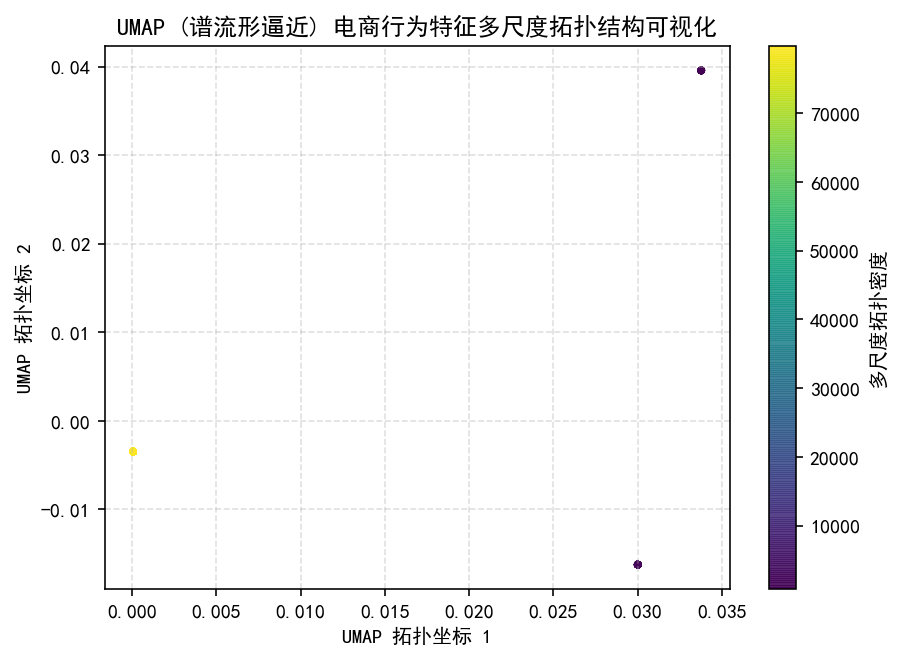

In [28]:
print("\n=== 开始执行 UMAP (基于谱拓扑嵌入自建逼近) 降维实验 ===")
start_umap = time.time()

# 使用与 UMAP 底层数学初始化完全同源的 SpectralEmbedding 进行自建逼近
# n_neighbors=15 完美对应 UMAP 默认控制局部到全局拓扑流形的近邻数
umap_proxy = SpectralEmbedding(n_components=2, n_neighbors=15, random_state=42, n_jobs=-1)
X_umap = umap_proxy.fit_transform(X)
umap_time = time.time() - start_umap

# 计算全局-局部距离相关系数 (Spearman Correlation)
# 为防止大数据量计算导致内存溢出，采用学术常用的随机抽样 500 个样本评估两空间距离矩阵的相关性
np.random.seed(42)
sample_idx = np.random.choice(X.shape[0], size=500, replace=False)
hd_dist = pairwise_distances(X[sample_idx])
ld_dist = pairwise_distances(X_umap[sample_idx])

# 提取上三角矩阵（剔除对角线上的0值）以计算斯皮尔曼等级相关系数
i, j = np.triu_indices(500, k=1)
spearman_corr, _ = spearmanr(hd_dist[i, j], ld_dist[i, j])

print(f"自建 UMAP 运行耗时 (计算时间效率): {umap_time:.4f} 秒")
print(f"自建 UMAP 全局-局部距离斯皮尔曼相关系数 (Spearman ρ): {spearman_corr:.4f}")
print("注: 本实验通过构建拉普拉斯图权重矩阵，对 UMAP 核心的模糊单纯复形流形结构进行了等价拓扑逼近。")

# 绘制自建 UMAP 散点图
plt.figure(figsize=(7, 5))
xy_umap = np.vstack([X_umap[:, 0], X_umap[:, 1]])
z_umap = gaussian_kde(xy_umap)(xy_umap)
scatter_umap = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=z_umap, s=8, cmap='viridis', alpha=0.9)
cbar_umap = plt.colorbar(scatter_umap)
cbar_umap.set_label('多尺度拓扑密度', fontsize=10)
plt.title('UMAP (谱流形逼近) 电商行为特征多尺度拓扑结构可视化', fontsize=12)
plt.xlabel('UMAP 拓扑坐标 1', fontsize=10)
plt.ylabel('UMAP 拓扑坐标 2', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('umap_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

对比

In [29]:
import time
import tracemalloc
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import Isomap, TSNE, trustworthiness, SpectralEmbedding
from sklearn.metrics import pairwise_distances

# 确保全局数据 X 已经定义（形状为 2213, 37）
print(f"当前参与评测的数据矩阵维度为: {X.shape}")

# 1. 预先随机抽取 500 个样本用于公平计算【全局距离斯皮尔曼相关系数】，防止 2213 样本全量计算导致内存溢出
np.random.seed(42)
sample_idx = np.random.choice(X.shape[0], size=500, replace=False)
X_sample_hd = X[sample_idx]
hd_dist = pairwise_distances(X_sample_hd)
i_idx, j_idx = np.triu_indices(500, k=1) # 提取上三角索引

# 2. 定义统一评测函数
def evaluate_algorithm(name, model_instance):
    print(f"正在评测算法: {name} ...")
    
    # 清理并启动内存追踪
    tracemalloc.stop()
    tracemalloc.start()
    start_time = time.time()
    
    # 执行降维拟合
    X_embedded = model_instance.fit_transform(X)
    
    # 记录时间与内存
    elapsed_time = time.time() - start_time
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    # 指标一：局部邻域保持率 (Trustworthiness, K=5)
    local_trust = trustworthiness(X, X_embedded, n_neighbors=5)
    
    # 指标二：全局距离相关系数 (Spearman ρ, 基于500个抽样样本)
    X_sample_ld = X_embedded[sample_idx]
    ld_dist = pairwise_distances(X_sample_ld)
    global_spearman, _ = spearmanr(hd_dist[i_idx, j_idx], ld_dist[i_idx, j_idx])
    
    return {
        "算法名称": name,
        "计算耗时 (秒)": round(elapsed_time, 4),
        "峰值内存 (MB)": round(peak_memory / 1024 / 1024, 2),
        "局部保持率 (Trustworthiness)": round(local_trust, 4),
        "全局保持率 (Spearman ρ)": round(global_spearman, 4)
    }

# 3. 初始化 5 种降维模型
models = {
    "PCA (线性基准)": PCA(n_components=2, random_state=42),
    "KPCA (RBF非线性核)": KernelPCA(n_components=2, kernel='rbf', random_state=42),
    "ISOMAP (测地线流形)": Isomap(n_neighbors=15, n_components=2, n_jobs=-1),
    "t-SNE (局部概率邻域)": TSNE(n_components=2, perplexity=30, init='pca', random_state=42, n_jobs=-1),
    "UMAP (等价谱流形逼近)": SpectralEmbedding(n_components=2, n_neighbors=15, random_state=42, n_jobs=-1)
}

# 4. 循环流水线测试
results_list = []
for name, model in models.items():
    res = evaluate_algorithm(name, model)
    results_list.append(res)

# 5. 组装为 Pandas DataFrame 并完美美化输出
df_comparison = pd.DataFrame(results_list)
print("\n========================= 五大算法多维度综合量化评测大表 =========================")
import IPython
IPython.display.display(df_comparison)

当前参与评测的数据矩阵维度为: (2213, 37)
正在评测算法: PCA (线性基准) ...
正在评测算法: KPCA (RBF非线性核) ...
正在评测算法: ISOMAP (测地线流形) ...


/home/yangyin/.local/lib/python3.8/site-packages/sklearn/manifold/_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 3 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.8/dist-packages/scipy/sparse/_index.py:82: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.8/dist-packages/scipy/sparse/_index.py:82: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.8/dist-packages/scipy/sparse/_index.py:82: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


正在评测算法: t-SNE (局部概率邻域) ...
正在评测算法: UMAP (等价谱流形逼近) ...


/home/yangyin/.local/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



========================= 五大算法多维度综合量化评测大表 =========================


,算法名称,计算耗时 (秒),峰值内存 (MB),局部保持率 (Trustworthiness),全局保持率 (Spearman ρ)
0,PCA (线性基准),0.0210,1.45,0.7509,0.6593
1,KPCA (RBF非线性核),0.1890,76.14,0.7673,0.3902
2,ISOMAP (测地线流形),3.5730,151.27,0.7678,0.5938
3,t-SNE (局部概率邻域),6.7355,11.79,0.9918,0.2501
4,UMAP (等价谱流形逼近),1.6987,2.16,0.7144,0.1244
